# Sales Prediction Using Python

## Project Overview

The objective of this project is to analyze advertising data and build a basic machine learning model that can predict sales based on advertising expenditure.

The dataset contains advertising expenditure on:
- TV
- Radio
- Newspaper

The project includes data exploration, visualization, and building a machine learning model to predict sales.

## 1. Importing Libraries

First, we import the required libraries for data analysis, visualization, and machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 2. Loading the Dataset

Let's load the advertising dataset and take a look at the first few rows.

In [2]:
df = pd.read_csv("advertising.csv")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## 3. Understanding the Dataset

Before analyzing the data, let's understand its size, columns, data types, and basic statistics.

In [3]:
df.shape

(200, 4)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## 4. Checking Missing and Duplicate Values

Before analyzing the data, we check whether the dataset contains any missing or duplicate values.

In [6]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [7]:
df[df.duplicated()]

,TV,Radio,Newspaper,Sales


The dataset does not contain any missing or duplicate values, so no additional data cleaning is required.

## 5. Exploratory Data Analysis

Now let's explore the relationship between advertising expenditure and sales using visualizations.

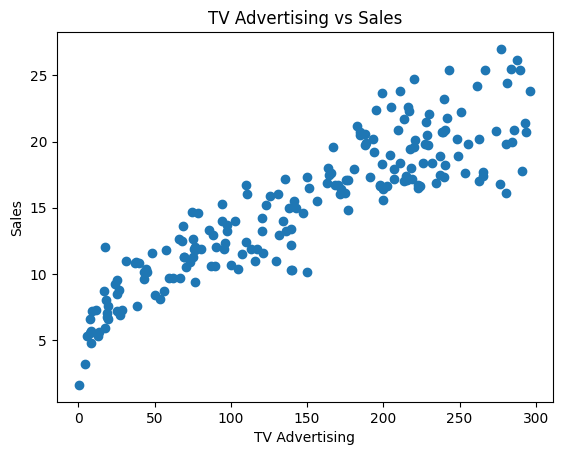

In [8]:
plt.scatter(df["TV"], df["Sales"])

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.show()

The graph shows a positive relationship between TV advertising expenditure and sales. Higher TV advertising expenditure generally appears to be associated with higher sales.

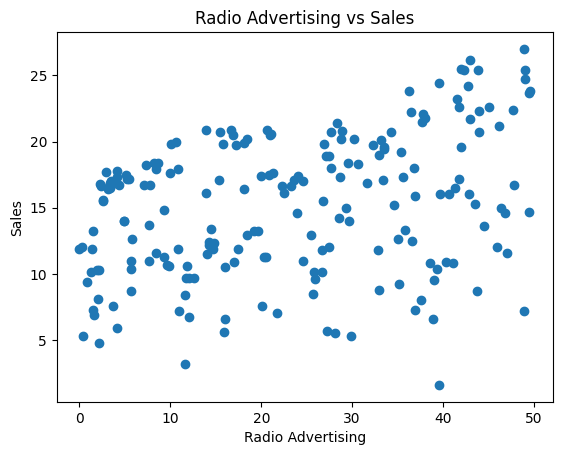

In [9]:
plt.scatter(df["Radio"], df["Sales"])

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.show()

The graph shows the relationship between radio advertising expenditure and sales.

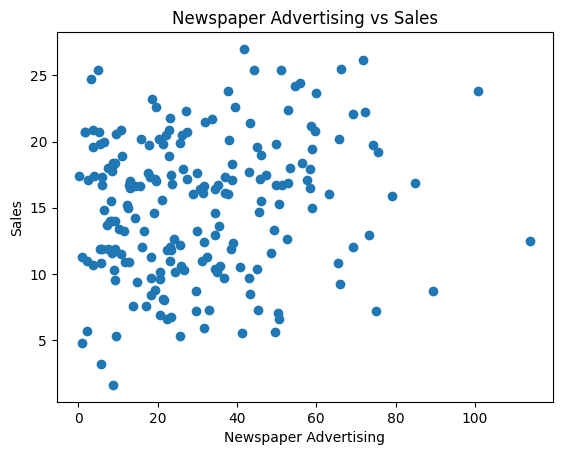

In [10]:
plt.scatter(df["Newspaper"], df["Sales"])

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.show()

The graph shows the relationship between newspaper advertising expenditure and sales.

## 6. Preparing the Data for Machine Learning

For this project, advertising expenditure on TV, Radio, and Newspaper will be used as input features.

The Sales column will be the target that we want to predict.

In [11]:
X = df.drop("Sales", axis=1)

y = df["Sales"]

## 7. Splitting the Dataset

The dataset is divided into training and testing data.

The model will learn from the training data, while the testing data will be used to evaluate its performance on unseen data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 8. Training the Model

We will use a Linear Regression model to learn the relationship between advertising expenditure and sales.

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 9. Making Predictions

Now that the model has been trained, we use it to predict sales for the testing data.

In [14]:
y_pred = model.predict(X_test)

y_pred[:10]

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475])

## 10. Comparing Actual and Predicted Sales

Let's compare some of the actual sales values with the values predicted by the model.

In [15]:
comparison = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
95,16.9,17.034772
15,22.4,20.409740
30,21.4,23.723989
158,7.3,9.272785
128,24.7,21.682719
115,12.6,12.569402
69,22.3,21.081195
170,8.4,8.690350
174,16.5,17.237013
45,16.1,16.666575


## 11. Evaluating the Model

Finally, we evaluate how well the model predicts sales using the R² score.

In [16]:
score = r2_score(y_test, y_pred)

print("R² Score:", round(score, 2))

R² Score: 0.91


R² tells us how well the model explains or predicts the variation in sales. A value closer to 1 generally indicates a better fit.

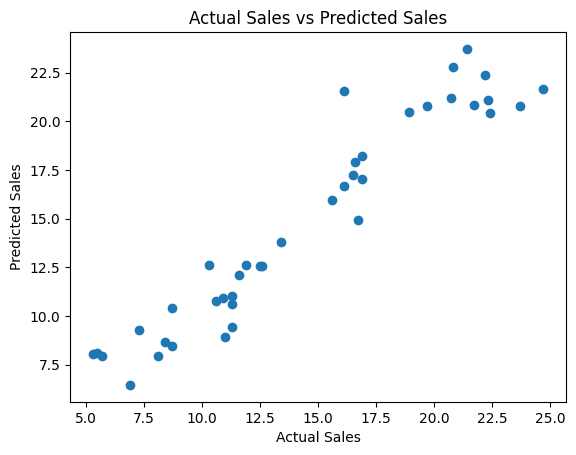

In [17]:
plt.scatter(y_test, y_pred)

plt.title("Actual Sales vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()

## 12. Conclusion

In this project, we explored the advertising dataset and analyzed the relationship between advertising expenditure and sales.

We used TV, Radio, and Newspaper advertising expenditure as input features and trained a Linear Regression model to predict sales.

The model was then used to make predictions on testing data and its performance was evaluated using the R² score.

This project demonstrates a basic regression workflow using Python and machine learning.